In [1]:
from lib_analysis import *
%matplotlib inline

cat_lolss_file = '../LoLSS_DR1_rolling.srl.fits'
# TEST
#cat_lolss = '../chan/LoLSS_DR1_rolling-chan03.srl.fits'

def binning(x,y,nbins, log=True):
    """
    returns:
    1. bin centers
    2. bin median value
    3. size of the bin to be used for xerr
    4. bin_std to be used for yerr (median absolute deviation)
    """
    import scipy.stats as stats
    bins = stats.mstats.mquantiles(x, np.linspace(0,1,nbins+1))
    bin_med, bin_edges, binnumber = stats.binned_statistic(x, y, statistic='median', bins=bins)
    if log: bin_std, bin_edges, binnumber = stats.binned_statistic(x, np.log(y), statistic=median_absolute_deviation, bins=bins) # in log to make input of std() symmetric
    else: bin_std, bin_edges, binnumber = stats.binned_statistic(x, y, statistic=median_absolute_deviation, bins=bins)
    bin_centers, bin_edges, binnumber = stats.binned_statistic(x, x, statistic='median', bins=bins)
    bin_xsize = [[bin_centers[i]-bin_edges[i],bin_edges[i+1]-bin_centers[i]] for i in range(len(bin_centers))]
    bin_xsize = list(map(list, zip(*bin_xsize))) # transpose
    if log: bin_std = [np.abs(np.exp(np.log(bin_med)-bin_std)-bin_med),np.abs(np.exp(np.log(bin_med)+bin_std)-bin_med)] # propagation of the interval (not error)
    #else: bin_std
    return bin_centers, bin_med, bin_xsize, bin_std

In [2]:
# Load all catalogues

#########
# prepare function returning spidx as a function of flux (@150 MHz)
from scipy import interpolate
spidx_fit = np.array([-0.688,-0.724,-0.746,-0.759,-0.769,-0.778,-0.787])
#spidx_fit = np.array([-0.759,-0.769,-0.778,-0.787])
flux_fit = np.array([10**(-1.25),10**(-1.15),10**(-1.05),10**(-0.95),10**(-0.8),10**(-0.6),10**(-0.4)])
#flux_fit = np.array([10**(-0.95),10**(-0.8),10**(-0.6),10**(-0.4)])
z = interpolate.interp1d(flux_fit*1e3, spidx_fit, fill_value='extrapolate') # mJy -> spidx
#########

# use only isolated sources
print('Loading...')
cat_lolss = isolated(Table.read(cat_lolss_file), dist=15*2); cat_lolss.rename_column('Total_flux', 'flux_lolss')
cat_8c = isolated(Table.read('/home/fdg/phd/obs/catalogues/8c.fits'), dist=60*4.5*2); cat_8c.rename_column('F_int', 'flux_8c')
cat_vlss = isolated(Table.read('/home/fdg/phd/obs/catalogues/VLSSr.fits'), dist=75*2); cat_vlss.rename_column('Total_flux', 'flux_vlss')
#cat_lotss = isolated(Table.read('/home/fdg/phd/obs/catalogues/LoTSS_DR2_v110.srl.fits'), dist=15*2); cat_lotss.rename_column('Total_flux', 'flux_lotss')
cat_lotss = isolated(Table.read('../LoTSS-cut.fits'), dist=30); cat_lotss.rename_column('Total_flux', 'flux_lotss')
cat_nvss = isolated(Table.read('/home/fdg/phd/obs/catalogues/NVSS.fits'), dist=45*2); cat_nvss.rename_column('Total_flux', 'flux_nvss')
cat_lolss_pdr = isolated(Table.read('../../preliminary_release/LoLSSv3-cat.fits'), dist= 45*2); cat_lolss_pdr.rename_column('Total_flux', 'flux_lolss_pdr'); cat_lolss_pdr.rename_column('E_Total_flux', 'fluxerr_lolss_pdr')

# restrict to compact for lotss (will be used later)
snr = cat_lotss['flux_lotss']/cat_lotss['E_Total_flux']
R = 0.42+(1.08/( 1 + (snr/96.57)**(2.49) ))
cat_lotss['is_pnt'] = (R > np.log(cat_lotss['flux_lotss']/cat_lotss['Peak_flux'])) 
print('Is pnt (LoTSS) %f%%' % (100*sum(cat_lotss['is_pnt'])/len(cat_lotss)))

cat_full = cat_lolss

print('Setting up....')
spidx_scale = -0.783

# to mJy
cat_8c['flux_8c'] *= 1e3
cat_vlss['flux_vlss'] *= 1e3
cat_nvss['flux_nvss'] *= 1e3

# names and freqs
surveys = ['8c','lolss','vlss','lotss','tgss','6c','3c','nvss']
surveys_freq = np.array([38,54,74,144,150,151,178,1400])*1e6

# add rescaled values
cat_8c['flux_resc_8c'] = cat_8c['flux_8c']*(54/38.)**(spidx_scale)
cat_vlss['flux_resc_vlss'] = cat_vlss['flux_vlss']*(54/74.)**(spidx_scale)
cat_lotss['flux_resc_lotss'] = cat_lotss['flux_lotss']*(54/144.)**(spidx_scale)
cat_lotss['flux_resc_smooth_lotss'] = cat_lotss['flux_lotss']*(54/144.)**(z(cat_lotss['flux_lotss']))
cat_nvss['flux_resc_nvss'] = cat_nvss['flux_nvss']*(54/1400.)**(spidx_scale)

# rms values
rms_8c = 2*1000 # mjy/b
rms_lolss = 1.6*4 # mjy/b
rms_vlss = 4*100 # mjy/b
rms_lotss = 3*100e-3 # mjy/b
rms_nvss = 5*0.45 # mjy/b

# rescale rms
rms_resc_8c = rms_8c * (54/38.)**(spidx_scale)
rms_resc_vlss = rms_vlss * (54/74.)**(spidx_scale)
rms_resc_lotss = rms_lotss * (54/144.)**(spidx_scale)
rms_resc_nvss = rms_nvss * (54/1400.)**(spidx_scale)

print('Matching....')

# 8c
cat_full = cross_match(cat_full, cat_8c, columns_to_keep=['flux_8c','flux_resc_8c'], dist=30)
print('Match 8c: %i' % sum(cat_full['flux_8c'] != 0))

# check no bright un-matched sources are within the 8c beam
catalog = SkyCoord(ra=cat_full['RA'], dec=cat_full['DEC'])
for match8c in cat_full[cat_full['flux_8c'] != 0]:
    c = SkyCoord(ra = match8c['RA']*u.degree, dec = match8c['DEC']*u.degree)
    dists = c.separation(catalog)
    #print(match8c['Source_name'],)
    #print("# close:",np.sum(dists<(4.5*60*u.arcsec))) # number of lolss sources within a beam of a matched 8c
    near_source_fluxes = cat_full[np.array(dists<(4.5*60*u.arcsec))]['flux_lolss']
    # identify if there's a source with > 10% of the flux of the match nearby
    if np.sum(sorted(near_source_fluxes)[:-1])/sorted(near_source_fluxes)[-1] > 0.1:
        print("WARNING:",match8c['Source_name']," max flux", sorted(near_source_fluxes)[-1], "- sum of the rest:", np.sum(sorted(near_source_fluxes)[:-1]))
        cat_full['flux_8c'][cat_full['Source_name'] == match8c['Source_name']] = 0
        
print('Match 8c (after removing problematic sources): %i' % sum(cat_full['flux_8c'] != 0))

# VLSS
cat_full = cross_match(cat_full, cat_vlss, columns_to_keep=['flux_vlss','flux_resc_vlss'], dist=20)
print('Match VLSSr: %i' % sum(cat_full['flux_vlss'] != 0))

# LoTSS
cat_full = cross_match(cat_full, cat_lotss, columns_to_keep=['flux_lotss','flux_resc_lotss','flux_resc_smooth_lotss','is_pnt'], dist=5)
print('Match LoTSS: %i' % sum(cat_full['flux_lotss'] != 0))

# NVSS
cat_full = cross_match(cat_full, cat_nvss, columns_to_keep=['flux_nvss','flux_resc_nvss'], dist=10)
print('Match NVSS: %i' % sum(cat_full['flux_nvss'] != 0))

# LoLSS PDR
cat_full = cross_match(cat_full, cat_lolss_pdr, columns_to_keep=['flux_lolss_pdr', 'fluxerr_lolss_pdr'], dist=10)
print('Match LoLSS PDR: %i' % sum(cat_full['flux_lolss_pdr'] != 0))

for c in range(6):
    print('Working on channel %i' % c)
    cat_lolss_c = isolated(Table.read('../chan/LoLSS_DR1_rolling-chan%02i.srl.fits' % c), dist=15*2)
    cat_lolss_c.rename_column('Total_flux', 'flux_lolss_%i' % c)
    cat_lolss_c.rename_column('Isl_rms', 'rms_lolss_%i' % c)
    cat_full = cross_match(cat_full, cat_lolss_c, columns_to_keep=['flux_lolss_%i' % c, 'rms_lolss_%i' % c], dist=6)
    print('Match chan %i: %i' % (c, sum(cat_full['flux_lolss_%i' % c] != 0)))

# fix 3c196
#cat_full['flux_lolss_0']*=(1.037)
#cat_full['flux_lolss_1']*=(1.031)
#cat_full['flux_lolss_2']*=(1.027)
#cat_full['flux_lolss_3']*=(1.022)
#cat_full['flux_lolss_4']*=(1.020)
#cat_full['flux_lolss_5']*=(1.016)
    
# in band spidx
lolss_inband_freqs = [44.236+3.906*i for i in range(6)]
cat_full['spidx_lolss'] = 0.
cat_full['E_spidx_lolss'] = 0.
cat_full['spidx_wide_low'] = 0.
cat_full['E_spidx_wide_low'] = 0.
cat_full['spidx_wide_high'] = 0.
cat_full['E_spidx_wide_high'] = 0.
for source in cat_full:
    if (source['flux_lolss_0'] != 0) and (source['flux_lolss_1'] != 0) and (source['flux_lolss_2'] != 0) and (source['flux_lolss_3'] != 0) and (source['flux_lolss_4'] != 0) and (source['flux_lolss_5'] != 0):
        y = [source['flux_lolss_%i' % i] for i in range(6)]
        yerr = [source['rms_lolss_%i' % i] for i in range(6)]
        a,b,sa,sb = linearfit(lolss_inband_freqs, y, yerr=yerr, tolog=True)
        source['spidx_lolss'] = a; source['E_spidx_lolss'] = sa
    if (source['flux_lotss'] != 0):
        y = [source['flux_lolss'],source['flux_lotss']]
        a,b,sa,sb = linearfit([54,144], y, yerr=None, tolog=True)
        source['spidx_wide_low'] = a; source['E_spidx_wide_low'] = sa
    if (source['flux_lotss'] != 0) & (source['flux_nvss'] != 0):
        y = [source['flux_lotss'],source['flux_nvss']]
        a,b,sa,sb = linearfit([144,1400], y, yerr=None, tolog=True)
        source['spidx_wide_high'] = a; source['E_spidx_wide_high'] = sa
    
# define compact and high SNR
print('All sources:',len(cat_full))
cat_full['is_pnt'] =  (cat_full['S_Code'] == 'S') & (cat_full['flux_lolss']/cat_full['E_Total_flux'] > 10) #& cat_full['is_pnt']
print('Sources that are good ("is_pnt"):', sum(cat_full['is_pnt']))

# keep a copy
from copy import copy
cat_full_bkp = copy(cat_full)
cat_full.write('LoLSS-matched.fits', overwrite=True)

Loading...
Removing 339 out of 42463 source
Removing 578 out of 5859 source


Removing 4280 out of 92965 source
Removing 237344 out of 932316 source
Removing 219240 out of 1810672 source
Removing 267 out of 25247 source
Is pnt (LoTSS) 94.403516%
Setting up....
Matching....
Match 8c: 114
Match 8c (after removing problematic sources): 98
Match VLSSr: 2302
Match LoTSS: 29160
Match NVSS: 20339
Match LoLSS PDR: 19587
Working on channel 0
Removing 154 out of 22689 source
Match chan 0: 20845
Working on channel 1
Removing 186 out of 24511 source
Match chan 1: 22553
Working on channel 2
Removing 187 out of 25448 source
Match chan 2: 23484
Working on channel 3
Removing 252 out of 25456 source
Match chan 3: 23439
Working on channel 4
Removing 258 out of 23894 source
Match chan 4: 21869
Working on channel 5
Removing 226 out of 21659 source
Match chan 5: 19675


/usr/lib/python3/dist-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


All sources: 42124
Sources that are good ("is_pnt"): 11810


8c - reducing to 98 sources
8C meds: [1.23151219 0.90624249 1.00788045 0.92723614] median: 0.97894615
VLSS - reducing to 436 sources
VLSSr meds: [1.59934342 1.13704455 1.13914168 0.97458553 0.96368134 1.00945377] median: 1.0625811
LoTSS - reducing to 8660 sources
VLSSr meds: [1.1136435  1.12174679 1.09735773 1.06433353 1.07838804 1.07490039
 1.0697299  1.06263845 1.06057678 1.03789118 1.04422948 1.06453222] median: 1.0733423771096722
LoTSS meds smooth: [0.92541161 0.94206124 0.93042324 0.910333   0.93145375 0.93870884
 0.94837295 0.95933565 0.97975182 0.9915679  1.01675607 1.07081197] avg: 0.9620823358468158
NVSS - reducing to 8766 sources
VLSSr meds: [1.88445687 1.51507378 1.41236305 1.40854561 1.29058146 1.24157584
 1.16566157 1.18601584 1.14979708 1.03017211 1.01720822 1.00092125] median: 1.2556522


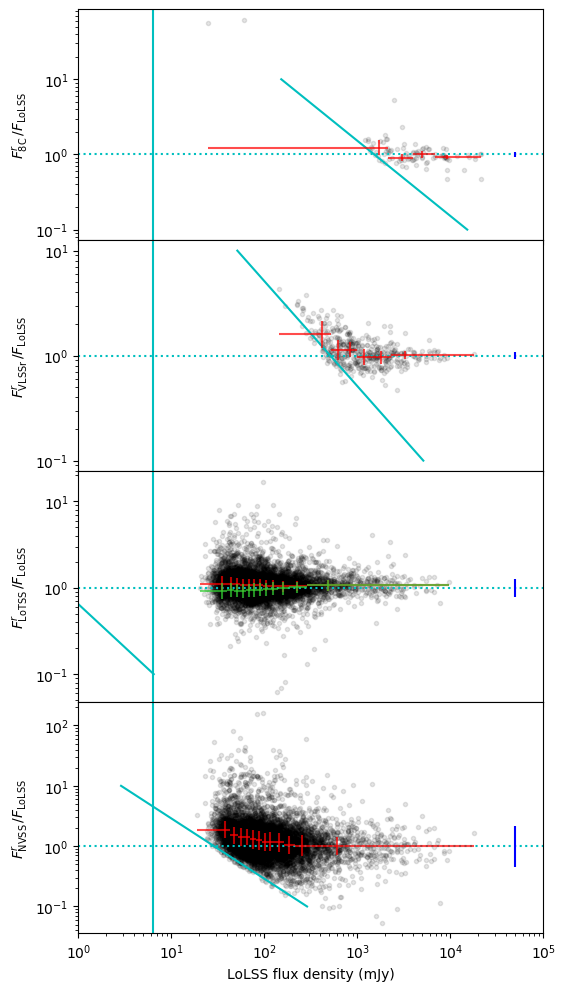

In [3]:
####################################################
# ratios
cat_full = copy(cat_full_bkp)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, figsize=(6,12), sharex=True)
fig.subplots_adjust(hspace=0)

# 8C
idx = (cat_full['flux_8c'] != 0)
print("8c - reducing to %i sources" % sum(idx))
ax1.set_ylabel(r'$F^r_{\rm 8C}\,/F_{\rm LoLSS}$')
x = cat_full['flux_lolss'][idx]
y = cat_full['flux_resc_8c'][idx]/cat_full['flux_lolss'][idx]
ax1.plot( x, y, '.k', alpha=0.1 )
ax1.plot([rms_resc_8c*10,rms_resc_8c/10],[1/10,10], ls='-', color='c')
ax1.axvline(rms_lolss, ls='-', color='c')
bin_centers, bin_med, bin_xerr, bin_std = binning(x,y,nbins=4)
print('8C meds:', bin_med, 'median:', np.median(y))
ax1.errorbar(bin_centers, bin_med, xerr=bin_xerr, yerr=bin_std, color='red', zorder=100, ls='', alpha=0.7)
ax1.axhline(1, ls=':', color='c')
ax1.set_xscale('log')
ax1.set_yscale('log')
#ax1.set_ylim(0.2,5)

exp_scatter = [[abs(1-(54/38.)**(0.24))], [abs(1-(54/38.)**(-0.24))]]
ax1.errorbar(5e4, 1, yerr=exp_scatter, color='blue', zorder=100, ls='', alpha=1)

# VLSS
idx = (cat_full['flux_vlss'] != 0) & cat_full['is_pnt']
print("VLSS - reducing to %i sources" % sum(idx))
ax2.set_ylabel(r'$F^r_{\rm VLSSr}\,/F_{\rm LoLSS}$')
x = cat_full['flux_lolss'][idx]
y = cat_full['flux_resc_vlss'][idx]/cat_full['flux_lolss'][idx]
ax2.plot( x, y, '.k', alpha=0.1 )
ax2.plot([rms_resc_vlss*10,rms_resc_vlss/10],[1/10,10], ls='-', color='c')
ax2.axvline(rms_lolss, ls='-', color='c')
bin_centers, bin_med, bin_xerr, bin_std = binning(x,y,nbins=6)
print('VLSSr meds:', bin_med, 'median:', np.median(y))
ax2.errorbar(bin_centers, bin_med, xerr=bin_xerr, yerr=bin_std, color='red', zorder=100, ls='', alpha=0.7)
ax2.axhline(1, ls=':', color='c')
ax2.set_xscale('log')
ax2.set_yscale('log')
#ax2.set_ylim(0.2,5)

exp_scatter = [[abs(1-(54/74.)**(0.24))], [abs(1-(54/74.)**(-0.24))]]
ax2.errorbar(5e4, 1, yerr=exp_scatter, color='blue', zorder=100, ls='', alpha=1)

# LoTSS
idx = (cat_full['flux_lotss'] != 0) & cat_full['is_pnt']
print("LoTSS - reducing to %i sources" % sum(idx))
ax3.set_ylabel(r'$F^r_{\rm LoTSS}\,/F_{\rm LoLSS}$')
x = cat_full['flux_lolss'][idx]
y = cat_full['flux_resc_lotss'][idx]/cat_full['flux_lolss'][idx]
y_smooth = cat_full['flux_resc_smooth_lotss'][idx]/cat_full['flux_lolss'][idx]
ax3.plot( x, y, '.k', alpha=0.1 )
ax3.plot([rms_resc_lotss*10,rms_resc_lotss/10],[1/10,10], ls='-', color='c')
ax3.axvline(rms_lolss, ls='-', color='c')
bin_centers, bin_med, bin_xerr, bin_std = binning(x,y,nbins=12)
print('VLSSr meds:', bin_med, 'median:', np.median(y))
ax3.errorbar(bin_centers, bin_med, xerr=bin_xerr, yerr=bin_std, color='red', zorder=100, ls='', alpha=0.7)
bin_centers, bin_med_smooth, bin_xerr, bin_std = binning(x,y_smooth,nbins=12)
print('LoTSS meds smooth:', bin_med_smooth, 'avg:', np.nanmean(bin_med_smooth))
ax3.errorbar(bin_centers, bin_med_smooth, xerr=bin_xerr, yerr=bin_std, color='limegreen', zorder=100, ls='', alpha=0.7)
ax3.axhline(1, ls=':', color='c')
ax3.set_xscale('log')
ax3.set_yscale('log')
#ax3.set_ylim(0.2,5)

exp_scatter = [[abs(1-(54/144.)**(0.24))], [abs(1-(54/144.)**(-0.24))]]
ax3.errorbar(5e4, 1, yerr=exp_scatter, color='blue', zorder=100, ls='', alpha=1)

# NVSS
idx = (cat_full['flux_nvss'] != 0) & cat_full['is_pnt']
print("NVSS - reducing to %i sources" % sum(idx))
ax4.set_ylabel(r'$F^r_{\rm NVSS}\,/F_{\rm LoLSS}$')
x = cat_full['flux_lolss'][idx]
y = cat_full['flux_resc_nvss'][idx]/cat_full['flux_lolss'][idx]
ax4.plot( x, y, '.k', alpha=0.1 )
ax4.plot([rms_resc_nvss*10,rms_resc_nvss/10],[1/10,10], ls='-', color='c')
ax4.axvline(rms_lolss, ls='-', color='c')
bin_centers, bin_med, bin_xerr, bin_std = binning(x,y,nbins=12)
print('VLSSr meds:', bin_med, 'median:', np.median(y))
ax4.errorbar(bin_centers, bin_med, xerr=bin_xerr, yerr=bin_std, color='red', zorder=100, ls='', alpha=0.7)
ax4.axhline(1, ls=':', color='c')
ax4.set_xscale('log')
ax4.set_yscale('log')
#ax4.set_ylim(0.2,5)

exp_scatter = [[abs(1-(54/1400.)**(0.24))], [abs(1-(54/1400.)**(-0.24))]]
ax4.errorbar(5e4, 1, yerr=exp_scatter, color='blue', zorder=100, ls='', alpha=1)

ax4.set_xlim(1,1e5)
ax4.set_xlabel(r'LoLSS flux density (mJy)')
fig.savefig('flux.png', bbox_inches='tight')


Match NVSS+LoTSS: 14645

['Source_name', 'RA', 'E_RA', 'DEC', 'E_DEC', 'flux_lolss', 'E_Total_flux', 'Peak_flux', 'E_Peak_flux', 'Maj', 'E_Maj', 'Min', 'E_Min', 'PA', 'E_PA', 'DC_Maj', 'E_DC_Maj', 'DC_Min', 'E_DC_Min', 'DC_PA', 'E_DC_PA', 'Isl_rms', 'S_Code', 'Mosaic_id', 'flux_8c', 'flux_resc_8c', 'flux_vlss', 'flux_resc_vlss', 'flux_lotss', 'flux_resc_lotss', 'flux_resc_smooth_lotss', 'is_pnt', 'flux_nvss', 'flux_resc_nvss', 'flux_lolss_pdr', 'fluxerr_lolss_pdr', 'flux_lolss_0', 'rms_lolss_0', 'flux_lolss_1', 'rms_lolss_1', 'flux_lolss_2', 'rms_lolss_2', 'flux_lolss_3', 'rms_lolss_3', 'flux_lolss_4', 'rms_lolss_4', 'flux_lolss_5', 'rms_lolss_5', 'spidx_lolss', 'E_spidx_lolss', 'spidx_wide_low', 'E_spidx_wide_low', 'spidx_wide_high', 'E_spidx_wide_high']
Match NVSS+LoTSS: 4895
Spidx meds: [1.07367918 1.07707696 1.09115225 1.08505054 1.13075935]
Median: 1.093043+/-0.006794 (MAD: 0.129810)
Match NVSS+LoTSS+8c: 59
Curved meds: [0.97353056]
Median: 0.973531+/-0.049381 (MAD: 0.062347)
Matc

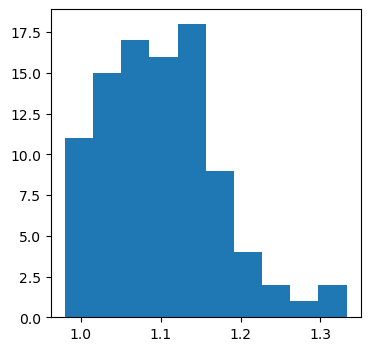

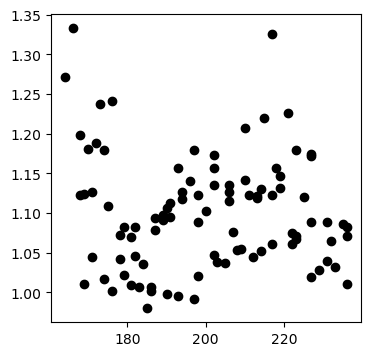

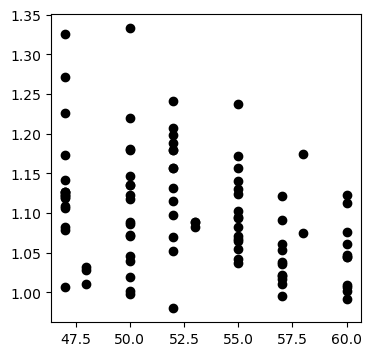

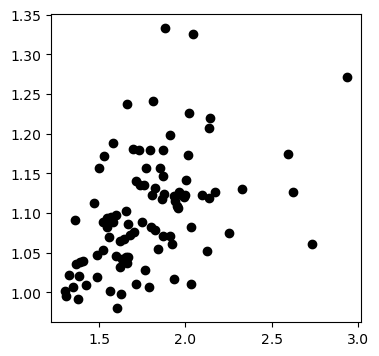

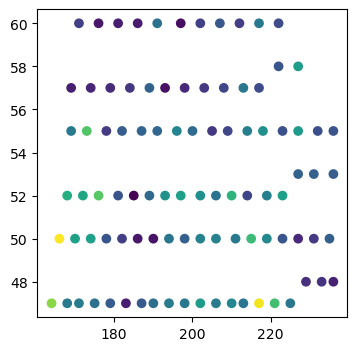

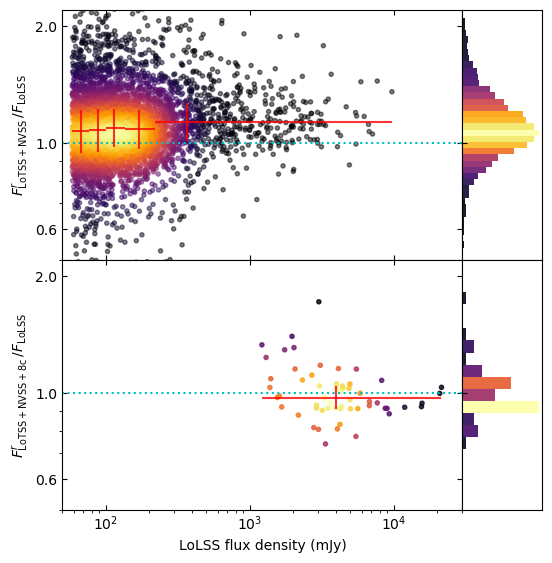

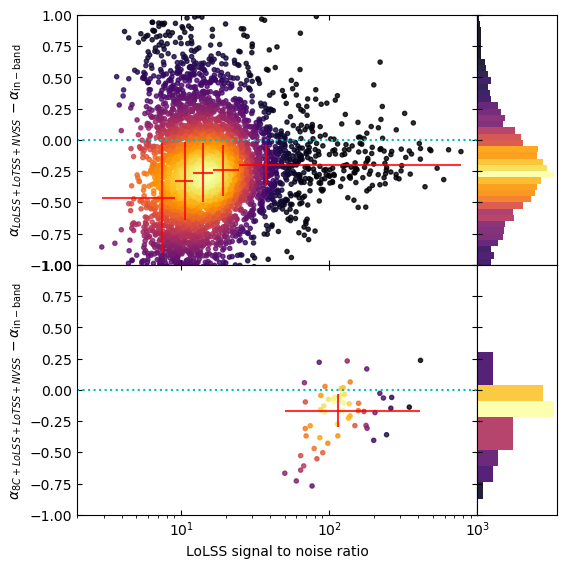

In [4]:
####################################################
# with spidx from surveys

cat_full = copy(cat_full_bkp)

# spidx LoTSS NVSS
idx = (cat_full['flux_lotss'] != 0) & (cat_full['flux_nvss'] != 0)
print('Match NVSS+LoTSS: %i' % sum(idx))
high_flux = cat_full[idx]['flux_nvss'] # NVSS
low_flux = cat_full[idx]['flux_lotss'] # LoTSS
lolss_flux = cat_full[idx]['flux_lolss']
# select good points - remove sources that are too faint not to be included if spidx between -0.2 and -1.2
idx_good = np.where((high_flux > rms_lolss*(1400/54.)**(-0.5)) & \
                    (low_flux > rms_lolss*(144/54.)**(-0.5)) & \
                    (high_flux > rms_lotss*(1400/144.)**(-0.5)) & \
                    (low_flux > rms_nvss*(144/1400.)**(-1.0)) & \
                    (lolss_flux > rms_lotss*(54/144.)**(-1.0)) & \
                    (lolss_flux > rms_nvss*(54/1400.)**(-1.0)) )
print('')

# remove sources that are too faint not to be included if spidx between -0.2 and -1.2
cat_full = cat_full[idx][idx_good]

################################################
# some tests
print(cat_full.keys())
# RA
#idx = (cat_full['flux_lotss'] != 0) & (cat_full['flux_nvss'] != 0) & cat_full['is_pnt'] & (cat_full['RA'] > np.median(cat_full['RA']))
#y = cat_full['spidx_wide_high'][idx]
#print(r"Median spidx - High RA: %.4f +/- %.4f" % (np.median(y),median_err(y)) )
#y = cat_full['spidx_wide_high'][~idx]
#print(r"Median spidx - Low RA: %.4f +/- %.4f" % (np.median(y),median_err(y)) )

# Dec
#idx = (cat_full['flux_lotss'] != 0) & (cat_full['flux_nvss'] != 0) & cat_full['is_pnt'] & (cat_full['DEC'] > np.median(cat_full['DEC']))
#y = cat_full['spidx_wide_high'][idx]
#print(r"Median spidx - High Dec: %.4f +/- %.4f" % (np.median(y),median_err(y)) )
#y = cat_full['spidx_wide_high'][~idx]
#print(r"Median spidx - Low Dec: %.4f +/- %.4f" % (np.median(y),median_err(y)) )

pointings = set(cat_full['Mosaic_id'])
spidxs = []; rmss = []; ras = []; decs = []
for pointing in pointings:
    idx = (cat_full['flux_lotss'] != 0) & (cat_full['flux_nvss'] != 0) & cat_full['is_pnt'] & (cat_full['Mosaic_id'] == pointing)
    y1 = cat_full['flux_lotss'][idx]*(54/144.)**cat_full['spidx_wide_high'][idx]/cat_full['flux_lolss'][idx]
    y2 = cat_full['Isl_rms'][idx]
    spidxs.append(np.median(y1))
    rmss.append(np.median(y2))
    ras.append(float(pointing[1:4]))
    decs.append(float(pointing[5:]))
    #if pointing in ['p202+52','p206+47','p206+52','p210+47','p211+50','p214+52','p215+50','p218+55','p219+52','p223+50','p223+55','p227+53','p205+55','p206+50','p209+55','p210+52','p213+47','p214+55','p217+47','p219+50','p221+47','p223+52','p225+47']:
        
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)
ax.hist(spidxs)
fig.savefig('fluxexp_hist_perfield.pdf', bbox_inches='tight')

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)
ax.plot(ras,spidxs,'ko')
fig.savefig('fluxexp_variation_ra.pdf', bbox_inches='tight')

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)
ax.plot(decs,spidxs,'ko')
fig.savefig('fluxexp_variation_dec.pdf', bbox_inches='tight')

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)
ax.plot(rmss,spidxs,'ko')
fig.savefig('fluxexp_variation_rms.pdf', bbox_inches='tight')

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)
ax.scatter(ras,decs,c=spidxs)
fig.savefig('fluxexp_variation_dec.pdf', bbox_inches='tight')

################################################
# definitions for the axes
left, width = 0.1, 1.0
bottom, height = 0.1, 0.5
spacing = 0.0
rect_scatter1 = [left, bottom + height, width, height]
rect_histy1 = [left + width + spacing, bottom + height, 0.2, height]
rect_scatter2 = [left, bottom, width, height]
rect_histy2 = [left + width + spacing, bottom, 0.2, height]

fig = plt.figure(figsize=(4, 5))

ax1 = plt.axes(rect_scatter1)
ax1.tick_params(direction='in', top=True, right=True)
ax1_histy = plt.axes(rect_histy1)
ax1_histy.tick_params(direction='in', labelleft=False)

ax2 = plt.axes(rect_scatter2)
ax2.tick_params(direction='in', top=True, right=True)
ax2_histy = plt.axes(rect_histy2)
ax2_histy.tick_params(direction='in', labelleft=False)

fig.subplots_adjust(hspace=0)

idx = (cat_full['flux_lotss'] != 0) & (cat_full['flux_nvss'] != 0) & cat_full['is_pnt']
print('Match NVSS+LoTSS: %i' % sum(idx))

ax1.set_ylabel(r'$F^r_{\rm LoTSS+NVSS}\,/F_{\rm LoLSS}$')
x = cat_full['flux_lolss'][idx]
y = cat_full['flux_lotss'][idx]*(54/144.)**cat_full['spidx_wide_high'][idx]/cat_full['flux_lolss'][idx]
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
ax1.scatter( x, y, marker='.', c=z, cmap=cm.inferno, alpha=.5 )
bin_centers, bin_med, bin_xerr, bin_std = binning(x,y,nbins=5)
print('Spidx meds:', bin_med)
print(r'Median: %f+/-%f (MAD: %f)' % (np.median(y),median_err(y),median_absolute_deviation(y)))
ax1.errorbar(bin_centers, bin_med, xerr=bin_xerr, yerr=bin_std, color='red', zorder=100, ls='', alpha=0.8)
ax1.axhline(1, ls=':', color='c')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim(0.5,2.2)

# histogram 1
bins = np.logspace(np.log10(0.5),np.log10(2+0.1), 40)
n, bins, patches = ax1_histy.hist(y, bins=bins, orientation='horizontal', color='black', alpha=0.9, histtype='bar')
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm.inferno(c))
ax1_histy.set_yscale('log')

### check curved spectra 8c LoTSS NVSS
idx = (cat_full['flux_8c'] != 0) & (cat_full['flux_nvss'] != 0) & (cat_full['flux_lotss'] != 0)
print('Match NVSS+LoTSS+8c: %i' % sum(idx))

fluxes = [cat_full['flux_8c'][idx], cat_full['flux_lotss'][idx], cat_full['flux_nvss'][idx]]  

p, p_err, _, _, _ = np.polyfit(np.log10([38e6,144e6,1400e6]), np.log10(fluxes), 2, full=True)
ax2.set_ylabel(r'$F^r_{\rm LoTSS+NVSS+8c}\,/F_{\rm LoLSS}$')
x = cat_full['flux_lolss'][idx]
y = 10**np.polyval(p, np.log10(54e6))/cat_full['flux_lolss'][idx]
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
ax2.scatter( x, y, marker='.', c=z, cmap=cm.inferno, alpha=.8 )
bin_centers, bin_med, bin_xerr, bin_std = binning(x,y,nbins=1)
print('Curved meds:', bin_med)
print(r'Median: %f+/-%f (MAD: %f)' % (np.median(y),median_err(y),median_absolute_deviation(y)))
ax2.errorbar(bin_centers, bin_med, xerr=bin_xerr, yerr=bin_std, color='red', zorder=100, ls='', alpha=0.8)
ax2.axhline(1, ls=':', color='c')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylim(0.5,2.2)

# histogram 2
bins = np.logspace(np.log10(0.5),np.log10(2+0.1), 21)
n, bins, patches = ax2_histy.hist(y, bins=bins, orientation='horizontal', color='black', alpha=0.9, histtype='bar')
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm.inferno(c))
ax2_histy.set_yscale('log')

ax1.set_xlim(50,3e4)
ax2.set_xlim(50,3e4)
ax2.set_xlabel(r'LoLSS flux density (mJy)')

ax1_histy.set_ylim(ax1.get_ylim())
ax2_histy.set_ylim(ax2.get_ylim())
ax1_histy.set_xticks([])
ax1_histy.set_yticks([], minor=True)
ax2_histy.set_xticks([], [])
ax2_histy.set_yticks([], minor=True)
#ax1.grid(alpha=.2)
#ax2.grid(alpha=.2)

from matplotlib.ticker import StrMethodFormatter, NullFormatter
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
ax1.yaxis.set_minor_formatter(NullFormatter())
ax2.yaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
ax2.yaxis.set_minor_formatter(NullFormatter())
ax1.set_yticks([0.6,1,2])
ax2.set_yticks([0.6,1,2])

fig.savefig('flux-exp.pdf', bbox_inches='tight')

########################################################################
# definitions for the axes
left, width = 0.1, 1.0
bottom, height = 0.1, 0.5
spacing = 0.0
rect_scatter1 = [left, bottom + height, width, height]
rect_histy1 = [left + width + spacing, bottom + height, 0.2, height]
rect_scatter2 = [left, bottom, width, height]
rect_histy2 = [left + width + spacing, bottom, 0.2, height]

fig = plt.figure(figsize=(4, 5))

ax1 = plt.axes(rect_scatter1)
ax1.tick_params(direction='in', top=True, right=True)
ax1_histy = plt.axes(rect_histy1)
ax1_histy.tick_params(direction='in', labelleft=False)

ax2 = plt.axes(rect_scatter2)
ax2.tick_params(direction='in', top=True, right=True)
ax2_histy = plt.axes(rect_histy2)
ax2_histy.tick_params(direction='in', labelleft=False)

fig.subplots_adjust(hspace=0)

# check expected spidx from curved LoLSS+LoTSS+NVSS and compare with in-band lolss
idx = (cat_full['flux_nvss'] != 0) & (cat_full['flux_lotss'] != 0) & (cat_full['spidx_lolss'] != 0) & cat_full['is_pnt']
print('Match NVSS+LoTSS+in-band: %i' % sum(idx))

fluxes = [cat_full['flux_lolss'][idx], cat_full['flux_lotss'][idx], cat_full['flux_nvss'][idx]]

p3, p3_err, _, _, _ = np.polyfit(np.log10([54e6,144e6,1400e6]), np.log10(fluxes), 2, full=True)
y=[]
for i in range(sum(idx)):
    p3der = np.polyder(p3.T[i], m=1) # derivata
    y.append(np.polyval(p3der,np.log10(54e6)))
#x = cat_full['flux_lolss'][idx]
x = cat_full['flux_lotss'][idx]/cat_full['E_Total_flux'][idx] # TEST
y -= cat_full['spidx_lolss'][idx]
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
ax1.scatter( x, y, marker='.', c=z, cmap=cm.inferno, alpha=.8 )
bin_centers, bin_med, bin_xerr, bin_std = binning(x, y, nbins=5, log=False)
print('Difference expected from curved (LoLSS+LoTSS+NVSS) and in-band meds')
print(r'Median: %f+/-%f (MAD: %f)' % (np.median(y),median_err(y),median_absolute_deviation(y)))
ax1.errorbar(bin_centers, bin_med, xerr=bin_xerr, yerr=bin_std, color='red', zorder=100, ls='', alpha=0.8)
ax1.axhline(0, ls=':', color='c')
ax1.set_ylabel(r'$\alpha_{LoLSS + LoTSS + NVSS}\, - \alpha_{\rm in-band}$')
ax1.set_ylim(-1,1)
ax1.set_xscale('log')

# histogram 1
bins = np.arange(-1, 1+0.05, 0.05)
n, bins, patches = ax1_histy.hist(y, bins=bins, orientation='horizontal', color='black', alpha=0.9, histtype='bar')
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm.inferno(c))

# check expected spidx from curved 8c+LoLSS+LoTSS+NVSS and compare with in-band lolss
idx = (cat_full['flux_8c'] != 0) & (cat_full['flux_nvss'] != 0) & (cat_full['flux_lotss'] != 0) & (cat_full['spidx_lolss'] != 0)
print('Match NVSS+LoTSS+8c+in-band: %i' % sum(idx))

fluxes = [cat_full['flux_8c'][idx], cat_full['flux_lolss'][idx], cat_full['flux_lotss'][idx], cat_full['flux_nvss'][idx]]

p3, p3_err, _, _, _ = np.polyfit(np.log10([38e6,54e6,144e6,1400e6]), np.log10(fluxes), 2, full=True)
y=[]
for i in range(sum(idx)):
    p3der = np.polyder(p3.T[i], m=1) # derivata
    y.append(np.polyval(p3der,np.log10(54e6)))
#x = cat_full['flux_lolss'][idx]
x = cat_full['flux_lotss'][idx]/cat_full['E_Total_flux'][idx] # TEST
y -= cat_full['spidx_lolss'][idx]
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
ax2.scatter( x, y, marker='.', c=z, cmap=cm.inferno, alpha=.8 )
bin_centers, bin_med, bin_xerr, bin_std = binning(x, y, nbins=1, log=False)
print('Difference expected from curved (8c+LoLSS+LoTSS+NVSS) and in-band')
print(r'Median: %f+/-%f (MAD: %f)' % (np.median(y),median_err(y),median_absolute_deviation(y)))
ax2.errorbar(bin_centers, bin_med, xerr=bin_xerr, yerr=bin_std, color='red', zorder=100, ls='', alpha=0.8)
ax2.axhline(0, ls=':', color='c')
ax2.set_ylabel(r'$\alpha_{8C + LoLSS + LoTSS + NVSS}\, - \alpha_{\rm in-band}$')
ax2.set_ylim(-1,1)   
ax2.set_xscale('log')

# histogram 2
bins = np.arange(-1, 1+0.05, 0.13)
n, bins, patches = ax2_histy.hist(y, bins=bins, orientation='horizontal', color='black', alpha=0.9, histtype='bar')
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm.inferno(c))

#ax1.set_xlim(50,3e4)
#ax2.set_xlim(50,3e4)
#ax2.set_xlabel(r'LoLSS flux density (mJy)')
ax1.set_xlim(2,1e3) # TEST
ax2.set_xlim(2,1e3)
ax2.set_xlabel(r'LoLSS signal to noise ratio')

ax1_histy.set_ylim(ax1.get_ylim())
ax2_histy.set_ylim(ax2.get_ylim())
ax1_histy.set_xticks([])
ax1_histy.set_yticks([], minor=True)
ax2_histy.set_xticks([], [])
ax2_histy.set_yticks([], minor=True)
#ax1.grid(alpha=.2)
#ax2.grid(alpha=.2)

#fig.savefig('spidxinband-exp.pdf', bbox_inches='tight')
fig.savefig('spidxinband-exp-snr.pdf', bbox_inches='tight')

Median ratio: 0.965039+/-0.002954 (MAD: 0.100146)


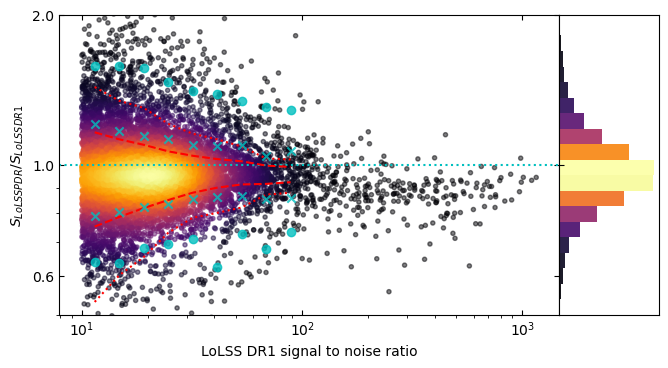

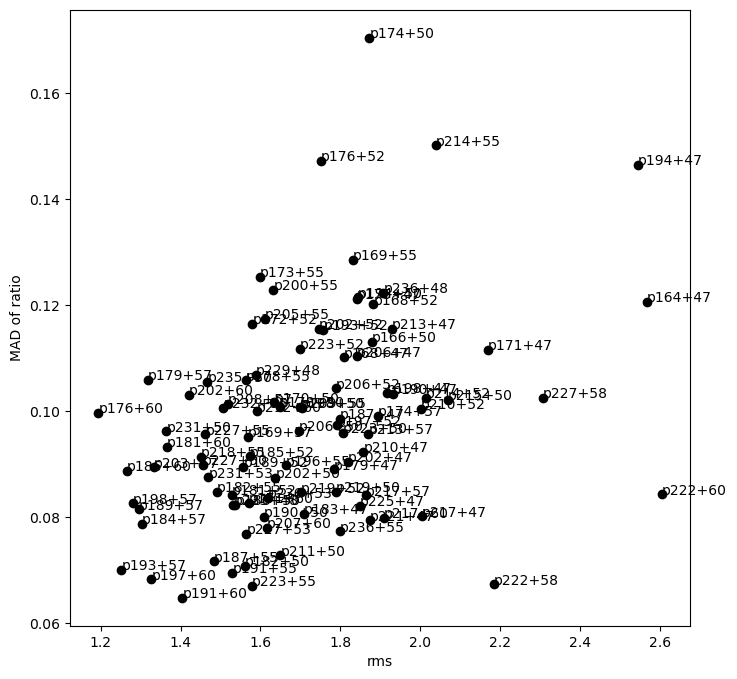

In [5]:
# Comparison with PDR
cat_full = copy(cat_full_bkp)
idx = (cat_full['flux_lolss_pdr'] != 0) & cat_full['is_pnt']

left, width = 0.1, 1.0
bottom, height = 0.1, 1.0
spacing = 0.0
rect_scatter1 = [left, bottom + height, width, height]
rect_histy1 = [left + width + spacing, bottom + height, 0.2, height]

fig = plt.figure(figsize=(5, 3))

ax = plt.axes(rect_scatter1)
ax.tick_params(direction='in', top=True, right=True)
ax_histy = plt.axes(rect_histy1)
ax_histy.tick_params(direction='in', labelleft=False)

x = cat_full[idx]['flux_lolss']/cat_full[idx]['E_Total_flux']
y = cat_full[idx]['flux_lolss_pdr']/cat_full[idx]['flux_lolss']
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
ax.scatter(x,y, marker='.', c=z, cmap=cm.inferno, alpha=.5)
ax.set_ylim(.5,2)
#ax.grid(alpha=.2)

# histogram
bins = np.logspace(np.log10(0.5),np.log10(2+0.1), 21)
n, bins, patches = ax_histy.hist(y, bins=bins, orientation='horizontal', color='black', alpha=0.9, histtype='bar')
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm.inferno(c))
ax_histy.set_yscale('log')

print(r'Median ratio: %f+/-%f (MAD: %f)' % (np.median(y),median_err(y),median_absolute_deviation(y)))

ax.axhline(1,color='c',ls=':')
ax.set_xscale('log')
ax.set_yscale('log')
ax_histy.set_ylim(ax.get_ylim())
ax_histy.set_xticks([])
ax_histy.set_yticks([], minor=True)

# predictions of errors
#rng = np.arange(10,1000,10)
#logy = np.log10(y)
#err = np.abs(np.median(logy))*np.sqrt((1/rng)**2+5*(1/rng)**2) # propagate snr assuming in PDF is 5 times lower
#ax.plot(rng,np.median(logy)+err,ls=':',color='r')
#ax.plot(rng,np.median(logy)-err,ls=':',color='r') 
#ax.plot(rng,np.median(logy)+err*2,ls=':',color='r')
#ax.plot(rng,np.median(logy)-err*2,ls=':',color='r')
# create a new set of fluxes
import scipy.stats as stats
bins = np.logspace(np.log10(min(x)), np.log10(100), num=10)

# on moch data
moch_fluxes = cat_full[idx]['flux_lolss']#np.random.uniform(5e-3,0.1,10000)
moch_fluxes_lolss = moch_fluxes + np.random.normal(0, cat_full[idx]['E_Total_flux'])
moch_fluxes_lolss_pdr = moch_fluxes*0.96 + np.random.normal(0, cat_full[idx]['fluxerr_lolss_pdr'])
moch_ratios = moch_fluxes_lolss_pdr/moch_fluxes_lolss

# debug
#dfig = plt.figure(figsize=(4, 4))
#dax = fig.add_subplot(111)
#dax.set_xlabel(r'moch_ratios')
#dax.set_ylabel(r'number')
#dax.plot(moch_fluxes_lolss,moch_fluxes_lolss_pdr, 'k.')
#dax.plot( cat_full[idx]['flux_lolss_pdr'], cat_full[idx]['flux_lolss'], 'k.')
#dax.hist(moch_ratios[np.where((moch_fluxes/moch_errors>10.0019875) & (moch_fluxes/moch_errors<12.91777836))], histtype='bar', bins=np.linspace(0.5,2,20))
#dfig.savefig('test.pdf', bbox_inches='tight')

bin_68l, bin_edges, binnumber = stats.binned_statistic(x, moch_ratios, statistic=lambda yy: np.percentile(yy, (100-68)/2.), bins=bins)
bin_68h, bin_edges, binnumber = stats.binned_statistic(x, moch_ratios, statistic=lambda yy: np.percentile(yy, (100-68)/2.+68), bins=bins)
bin_width = (bin_edges[1:] - bin_edges[:-1])
bin_centers = bin_edges[1:] - bin_width/2
ax.plot(bin_centers, bin_68l, 'r--', zorder=100, alpha=1)
ax.plot(bin_centers, bin_68h, 'r--', zorder=100, alpha=1)
bin_99l, bin_edges, binnumber = stats.binned_statistic(x, moch_ratios, statistic=lambda yy: np.percentile(yy, (100-95)/2), bins=bins)
bin_99h, bin_edges, binnumber = stats.binned_statistic(x, moch_ratios, statistic=lambda yy: np.percentile(yy, (100-95)/2+95), bins=bins)
bin_width = (bin_edges[1:] - bin_edges[:-1])
bin_centers = bin_edges[1:] - bin_width/2
ax.plot(bin_centers, bin_99l, 'r:', zorder=100, alpha=1)
ax.plot(bin_centers, bin_99h, 'r:', zorder=100, alpha=1)

# now on the real data
bin_68l, bin_edges, binnumber = stats.binned_statistic(x, y, statistic=lambda yy: np.percentile(yy, (100-68)/2), bins=bins)
bin_68h, bin_edges, binnumber = stats.binned_statistic(x, y, statistic=lambda yy: np.percentile(yy, (100-68)/2+68), bins=bins)
bin_width = (bin_edges[1:] - bin_edges[:-1])
bin_centers = bin_edges[1:] - bin_width/2
ax.scatter(bin_centers, bin_68l, color='c', zorder=100, marker='x', alpha=0.8)
ax.scatter(bin_centers, bin_68h, color='c', zorder=100, marker='x', alpha=0.8)
bin_99l, bin_edges, binnumber = stats.binned_statistic(x, y, statistic=lambda yy: np.percentile(yy, (100-95)/2), bins=bins)
bin_99h, bin_edges, binnumber = stats.binned_statistic(x, y, statistic=lambda yy: np.percentile(yy, (100-95)/2+95), bins=bins)
bin_width = (bin_edges[1:] - bin_edges[:-1])
bin_centers = bin_edges[1:] - bin_width/2
ax.scatter(bin_centers, bin_99l, color='c', zorder=100, marker='o', alpha=0.8)
ax.scatter(bin_centers, bin_99h, color='c', zorder=100, marker='o', alpha=0.8)

from matplotlib.ticker import StrMethodFormatter, NullFormatter
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_yticks([0.6,1,2])

ax.set_xlabel(r'LoLSS DR1 signal to noise ratio')
ax.set_ylabel(r'$S_{LoLSS PDR}/S_{LoLSS DR1}$')
fig.savefig('comparison_pdr.pdf', bbox_inches='tight')

ratio_mads = []; rms_medians = []; fields = []
for field in set(cat_full['Mosaic_id']):
    idx_field = cat_full['Mosaic_id'] == field
    y = cat_full[idx & idx_field]['flux_lolss_pdr']/cat_full[idx & idx_field]['flux_lolss']
    ratio_median = np.median(y)
    ratio_MAD = median_absolute_deviation(y)
    #print('%s: median = %f (MAD = %f)' % (field,ratio_median,ratio_MAD))
    rms_median = np.median(cat_full[idx & idx_field]['Isl_rms'])
    ratio_mads.append(ratio_MAD)
    rms_medians.append(rms_median)
    fields.append(field)
    
fig = plt.figure(figsize=(8, 8))
fig.subplots_adjust(wspace=0)
ax = fig.add_subplot(111)
ax.set_xlabel(r'rms')
ax.set_ylabel(r'MAD of ratio')
ax.plot(rms_medians, ratio_mads, 'ko')
for rms_median, ratio_mad, field in zip(rms_medians, ratio_mads, fields):
    ax.text(rms_median, ratio_mad, field)
fig.savefig('test.pdf', bbox_inches='tight')


(good points:9014)
Median in-band: -0.372863+/-0.010749 (MAD: 0.273990)
Median wide-high: -0.768984+/-0.003693 (MAD: 0.113726)
Median diff (lolss - wide high): 0.418241+/-0.010415
Median in-band: -0.372863+/-0.010749 (MAD: 0.273990)
Median wide-low: -0.679921+/-0.005167 (MAD: 0.140662)
Median diff (lolss - wide high): 0.305135+/-0.010099
Median diff (wide high - wide low): -0.090704+/-0.004705
Bins In-band spidx - Wide-band low spidx vs spidx-low: [0.40889798 0.36172891 0.31857253 0.34613225 0.29844672 0.2609585
 0.28791166 0.24218491 0.21268277 0.30933415]
Bins In-band spidx - Wide-band low spidx vs flux lolss: [0.36240714 0.37030149 0.3770243  0.34960747 0.33265376 0.288474
 0.28439802 0.29200795 0.28199321 0.24696819]
Median ratio flux_lolss/flux_in-band: 0.98815286


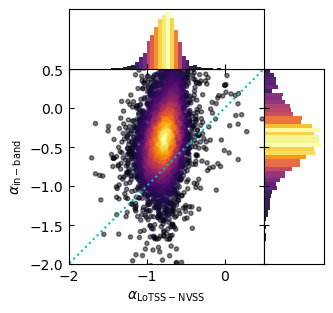

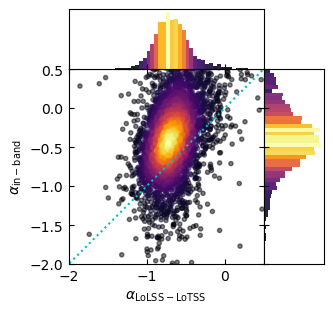

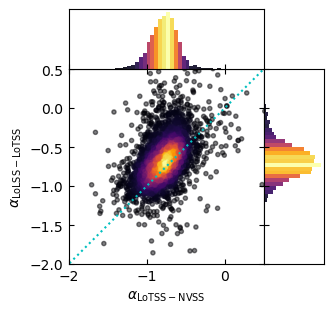

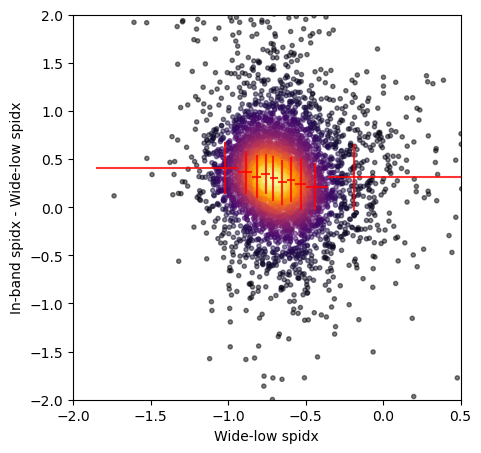

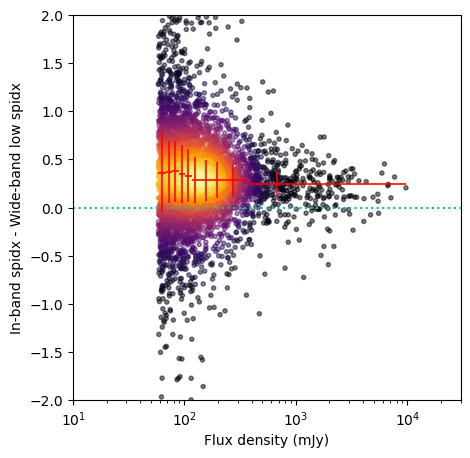

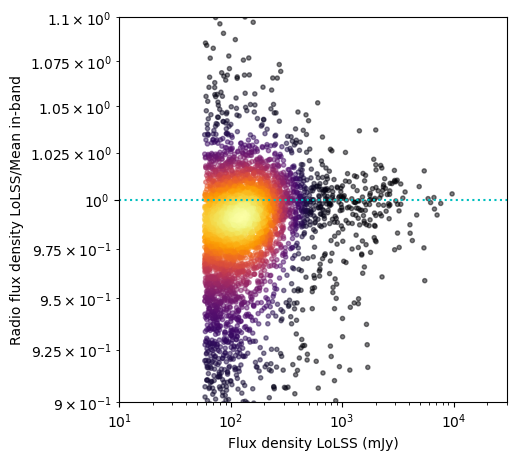

In [6]:
####################################################
# 

cat_full = copy(cat_full_bkp)
#cat_full['snr'] = cat_full['flux_lotss']/cat_full['E_Total_flux']
#cat_full = cat_full[cat_full['snr'] >20]

# restrig to unbiased region
idx = (cat_full['flux_nvss'] != 0) & (cat_full['flux_lotss'] != 0)
high_flux = cat_full[idx]['flux_nvss'] # NVSS
low_flux = cat_full[idx]['flux_lotss'] # LoTSS
lolss_flux = cat_full[idx]['flux_lolss']
spidx = np.log10(high_flux/low_flux)/np.log10(1400/144.)
# select good points - be sure all sources with spidx between -0.5 and -1.0 are included
idx_good = np.where((high_flux > rms_lolss*(1400/54.)**(-0.5)) & \
                    (low_flux > rms_lolss*(144/54.)**(-0.5)) & \
                    (high_flux > rms_lotss*(1400/144.)**(-0.5)) & \
                    (low_flux > rms_nvss*(144/1400.)**(-1.0)) & \
                    (lolss_flux > rms_lotss*(54/144.)**(-1.0)) & \
                    (lolss_flux > rms_nvss*(54/1400.)**(-1.0)) )
print('(good points:%i)' % len(idx_good[0]))
cat_full = cat_full[idx][idx_good]

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.00
rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

#####
idx = (cat_full['spidx_wide_high'] != 0) & (cat_full['spidx_lolss'] != 0) & cat_full['is_pnt']

fig = plt.figure(figsize=(3, 3))
fig.subplots_adjust(hspace=0)
ax = plt.axes(rect_scatter)
ax.tick_params(direction='in', top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.tick_params(direction='in', labelbottom=False)
ax_histy = plt.axes(rect_histy)
ax_histy.tick_params(direction='in', labelleft=False)

x = cat_full[idx]['spidx_wide_high']
y = cat_full[idx]['spidx_lolss']
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
ax.scatter(x,y, marker='.', c=z, cmap=cm.inferno, alpha=.5)
ax.plot([-3,1],[-3,1],'c:')
ax.set_xlim(-2,0.5)
ax.set_ylim(-2,0.5)
#ax.grid(alpha=.2)

# histograms
bins = np.arange(-2, 0.5 + 0.05, 0.05)
n, bins, patches = ax_histx.hist(x, bins=bins, color='black', alpha=0.9, histtype='bar', density=True)
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm.inferno(c))
n, bins, patches = ax_histy.hist(y, bins=bins, orientation='horizontal', color='black', alpha=0.9, histtype='bar', density=True)
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm.inferno(c))
ax_histx.set_yticks([], [])
ax_histy.set_xticks([], [])
ax_histx.set_xlim(ax.get_xlim())
ax_histy.set_ylim(ax.get_ylim())

print(r'Median in-band: %f+/-%f (MAD: %f)' % (np.median(cat_full[idx]['spidx_lolss']),median_err(cat_full[idx]['spidx_lolss']),median_absolute_deviation(cat_full[idx]['spidx_lolss'])))
print(r'Median wide-high: %f+/-%f (MAD: %f)' % (np.median(cat_full[idx]['spidx_wide_high']),median_err(cat_full[idx]['spidx_wide_high']),median_absolute_deviation(cat_full[idx]['spidx_wide_high'])))

ax.set_xlabel(r'$\alpha_{\rm LoTSS-NVSS}$')
ax.set_ylabel(r'$\alpha_{\rm in-band}$')
fig.savefig('inband_spidx-high.pdf', bbox_inches='tight')

diff = cat_full[idx]['spidx_lolss'] - cat_full[idx]['spidx_wide_high']
print('Median diff (lolss - wide high): %f+/-%f' % (np.median(diff), median_err(diff)))

#####
idx = (cat_full['spidx_wide_low'] != 0) & (cat_full['spidx_lolss'] != 0) & cat_full['is_pnt']

fig = plt.figure(figsize=(3, 3))
fig.subplots_adjust(hspace=0)
ax = plt.axes(rect_scatter)
ax.tick_params(direction='in', top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.tick_params(direction='in', labelbottom=False)
ax_histy = plt.axes(rect_histy)
ax_histy.tick_params(direction='in', labelleft=False)

x = cat_full[idx]['spidx_wide_low']
y = cat_full[idx]['spidx_lolss']
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
ax.scatter(x,y, marker='.', c=z, cmap=cm.inferno, alpha=.5)
ax.plot([-3,1],[-3,1],'c:')
ax.set_xlim(-2,0.5)
ax.set_ylim(-2,0.5)
#ax.grid(alpha=.2)

# histograms
bins = np.arange(-2, 0.5 + 0.05, 0.05)
n, bins, patches = ax_histx.hist(x, bins=bins, color='black', alpha=0.9, histtype='bar', density=True)
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm.inferno(c))
n, bins, patches = ax_histy.hist(y, bins=bins, orientation='horizontal', color='black', alpha=0.9, histtype='bar', density=True)
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm.inferno(c))
ax_histx.set_yticks([], [])
ax_histy.set_xticks([], [])
ax_histx.set_xlim(ax.get_xlim())
ax_histy.set_ylim(ax.get_ylim())

print(r'Median in-band: %f+/-%f (MAD: %f)' % (np.median(cat_full[idx]['spidx_lolss']),median_err(cat_full[idx]['spidx_lolss']),median_absolute_deviation(cat_full[idx]['spidx_lolss'])))
print(r'Median wide-low: %f+/-%f (MAD: %f)' % (np.median(cat_full[idx]['spidx_wide_low']),median_err(cat_full[idx]['spidx_wide_low']),median_absolute_deviation(cat_full[idx]['spidx_wide_low'])))

ax.set_xlabel(r'$\alpha_{\rm LoLSS-LoTSS}$')
ax.set_ylabel(r'$\alpha_{\rm in-band}$')
fig.savefig('inband_spidx-low.pdf', bbox_inches='tight')

diff = cat_full[idx]['spidx_lolss'] - cat_full[idx]['spidx_wide_low']
print('Median diff (lolss - wide high): %f+/-%f' % (np.median(diff), median_err(diff)))

#####
idx = (cat_full['spidx_wide_low'] != 0) & (cat_full['spidx_wide_high'] != 0) & cat_full['is_pnt']

fig = plt.figure(figsize=(3, 3))
fig.subplots_adjust(hspace=0)
ax = plt.axes(rect_scatter)
ax.tick_params(direction='in', top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.tick_params(direction='in', labelbottom=False)
ax_histy = plt.axes(rect_histy)
ax_histy.tick_params(direction='in', labelleft=False)

x = cat_full[idx]['spidx_wide_high']
y = cat_full[idx]['spidx_wide_low']
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
ax.scatter(x,y, marker='.', c=z, cmap=cm.inferno, alpha=.5)
ax.plot([-3,1],[-3,1],'c:')
ax.set_xlim(-2,0.5)
ax.set_ylim(-2,0.5)
#ax.grid(alpha=.2)

# histograms
bins = np.arange(-2, 0.5 + 0.05, 0.05)
n, bins, patches = ax_histx.hist(x, bins=bins, color='black', alpha=0.9, histtype='bar', density=True)
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm.inferno(c))
n, bins, patches = ax_histy.hist(y, bins=bins, orientation='horizontal', color='black', alpha=0.9, histtype='bar', density=True)
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm.inferno(c))
ax_histx.set_yticks([], [])
ax_histy.set_xticks([], [])
ax_histx.set_xlim(ax.get_xlim())
ax_histy.set_ylim(ax.get_ylim())

ax.set_xlabel(r'$\alpha_{\rm LoTSS-NVSS}$')
ax.set_ylabel(r'$\alpha_{\rm LoLSS-LoTSS}$')
fig.savefig('spidx-high-low.pdf', bbox_inches='tight')

diff = cat_full[idx]['spidx_wide_high'] - cat_full[idx]['spidx_wide_low']
print('Median diff (wide high - wide low): %f+/-%f' % (np.median(diff), median_err(diff)))

#####
idx = (cat_full['spidx_wide_low'] != 0) & (cat_full['spidx_lolss'] != 0) & cat_full['is_pnt']

fig, ax = plt.subplots(nrows=1, figsize=(5,5))
fig.subplots_adjust(hspace=0)
xy = np.vstack([cat_full[idx]['spidx_wide_low'],cat_full[idx]['spidx_lolss']-cat_full[idx]['spidx_wide_low']])
z = gaussian_kde(xy)(xy)
ax.scatter(cat_full[idx]['spidx_wide_low'],cat_full[idx]['spidx_lolss']-cat_full[idx]['spidx_wide_low'], marker='.', c=z, cmap=cm.inferno, alpha=.5)
ax.set_xlim(-2,0.5)
ax.set_ylim(-2,2)
#ax.grid(alpha=.2)

bin_centers, bin_med, bin_xerr, bin_std = binning(cat_full[idx]['spidx_wide_low'],cat_full[idx]['spidx_lolss']-cat_full[idx]['spidx_wide_low'],nbins=10,log=False)
ax.errorbar(bin_centers, bin_med, xerr=bin_xerr, yerr=bin_std, color='r', zorder=100, ls='', alpha=0.8)
print('Bins In-band spidx - Wide-band low spidx vs spidx-low:', bin_med)

ax.set_xlabel('Wide-low spidx')
ax.set_ylabel('In-band spidx - Wide-low spidx')
fig.savefig('inband_spidx-spidxlow.pdf', bbox_inches='tight')

#####
idx = (cat_full['spidx_wide_low'] != 0) & (cat_full['spidx_lolss'] != 0) & cat_full['is_pnt']

fig, ax = plt.subplots(nrows=1, figsize=(5,5))
fig.subplots_adjust(hspace=0)
xy = np.vstack([cat_full[idx]['flux_lolss'],cat_full[idx]['spidx_lolss']-cat_full[idx]['spidx_wide_low']])
z = gaussian_kde(xy)(xy)
ax.scatter(cat_full[idx]['flux_lolss'],cat_full[idx]['spidx_lolss']-cat_full[idx]['spidx_wide_low'], marker='.', c=z, cmap=cm.inferno, alpha=.5)
ax.set_xlim(10,30000)
ax.set_xscale('log')
ax.set_ylim(-2,+2)
#ax.grid(alpha=.2)
ax.axhline(0,color='c',ls=':')

bin_centers, bin_med, bin_xerr, bin_std = binning(cat_full[idx]['flux_lolss'],cat_full[idx]['spidx_lolss']-cat_full[idx]['spidx_wide_low'],nbins=10,log=False)
ax.errorbar(bin_centers, bin_med, xerr=bin_xerr, yerr=bin_std, color='r', zorder=100, ls='', alpha=0.8)
print('Bins In-band spidx - Wide-band low spidx vs flux lolss:', bin_med)

ax.set_xlabel('Flux density (mJy)')
ax.set_ylabel('In-band spidx - Wide-band low spidx')
fig.savefig('inband_spidx-flux.pdf', bbox_inches='tight')

#####
idx = (cat_full['spidx_lolss'] != 0) & cat_full['is_pnt']

fig, ax = plt.subplots(nrows=1, figsize=(5,5))
fig.subplots_adjust(hspace=0)
mean_fluxes = np.mean(np.array([cat_full[idx]['flux_lolss_0'],cat_full[idx]['flux_lolss_1'],cat_full[idx]['flux_lolss_2'],cat_full[idx]['flux_lolss_3'],cat_full[idx]['flux_lolss_4'],cat_full[idx]['flux_lolss_5']]), axis=0)
xy = np.vstack([cat_full[idx]['flux_lolss'], cat_full[idx]['flux_lolss']/mean_fluxes])
z = gaussian_kde(xy)(xy)
ax.scatter(cat_full[idx]['flux_lolss'], cat_full[idx]['flux_lolss']/mean_fluxes, marker='.', c=z, cmap=cm.inferno, alpha=.5)
print('Median ratio flux_lolss/flux_in-band:', np.median(cat_full[idx]['flux_lolss']/mean_fluxes))
ax.axhline(1,color='c',ls=":")
ax.set_xlim(10,30000)
ax.set_ylim(0.9,1.1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Flux density LoLSS (mJy)')
ax.set_ylabel('Radio flux density LoLSS/Mean in-band')
fig.savefig('inband_check.pdf', bbox_inches='tight')

Ncurves: 36
1 LOL1J134213.2+602142 205.55503069284026 60.36157072833273 -0.4296866601990548 -0.7315505591198086 -0.8505432598087407
2 LOL1J140248.5+573346 210.70208123030366 57.562867178720914 -0.7451316079476777 -0.857519383822237 -1.0084768530864727
3 LOL1J115603.7+584705 179.01544412277767 58.78473191902026 -0.5620544271911516 -0.7786470642416066 -0.6587733325920113
4 LOL1J111611.1+592000 169.04643329843728 59.33320957429107 -0.9253129529941594 -1.0587015259881685 -0.9938073227322981
5 LOL1J150257.9+610044 225.74144034594732 61.01223270710641 -0.9728461837517755 -1.0069965688943536 -0.9817982796784595
6 LOL1J114049.6+591225 175.20679209918436 59.20690858672424 0.1731238506701194 -0.13313104436036122 -0.5739007604345858
7 LOL1J150744.5+575648 226.9353850551639 57.94655465707185 -0.9806854596433827 -0.8938236662774393 -0.9841391117631965
8 LOL1J134741.0+581244 206.92082779434554 58.21211093290931 -0.8165083623445218 -0.8727745510673254 -0.763479493117234
9 LOL1J150135.8+565750 225.399

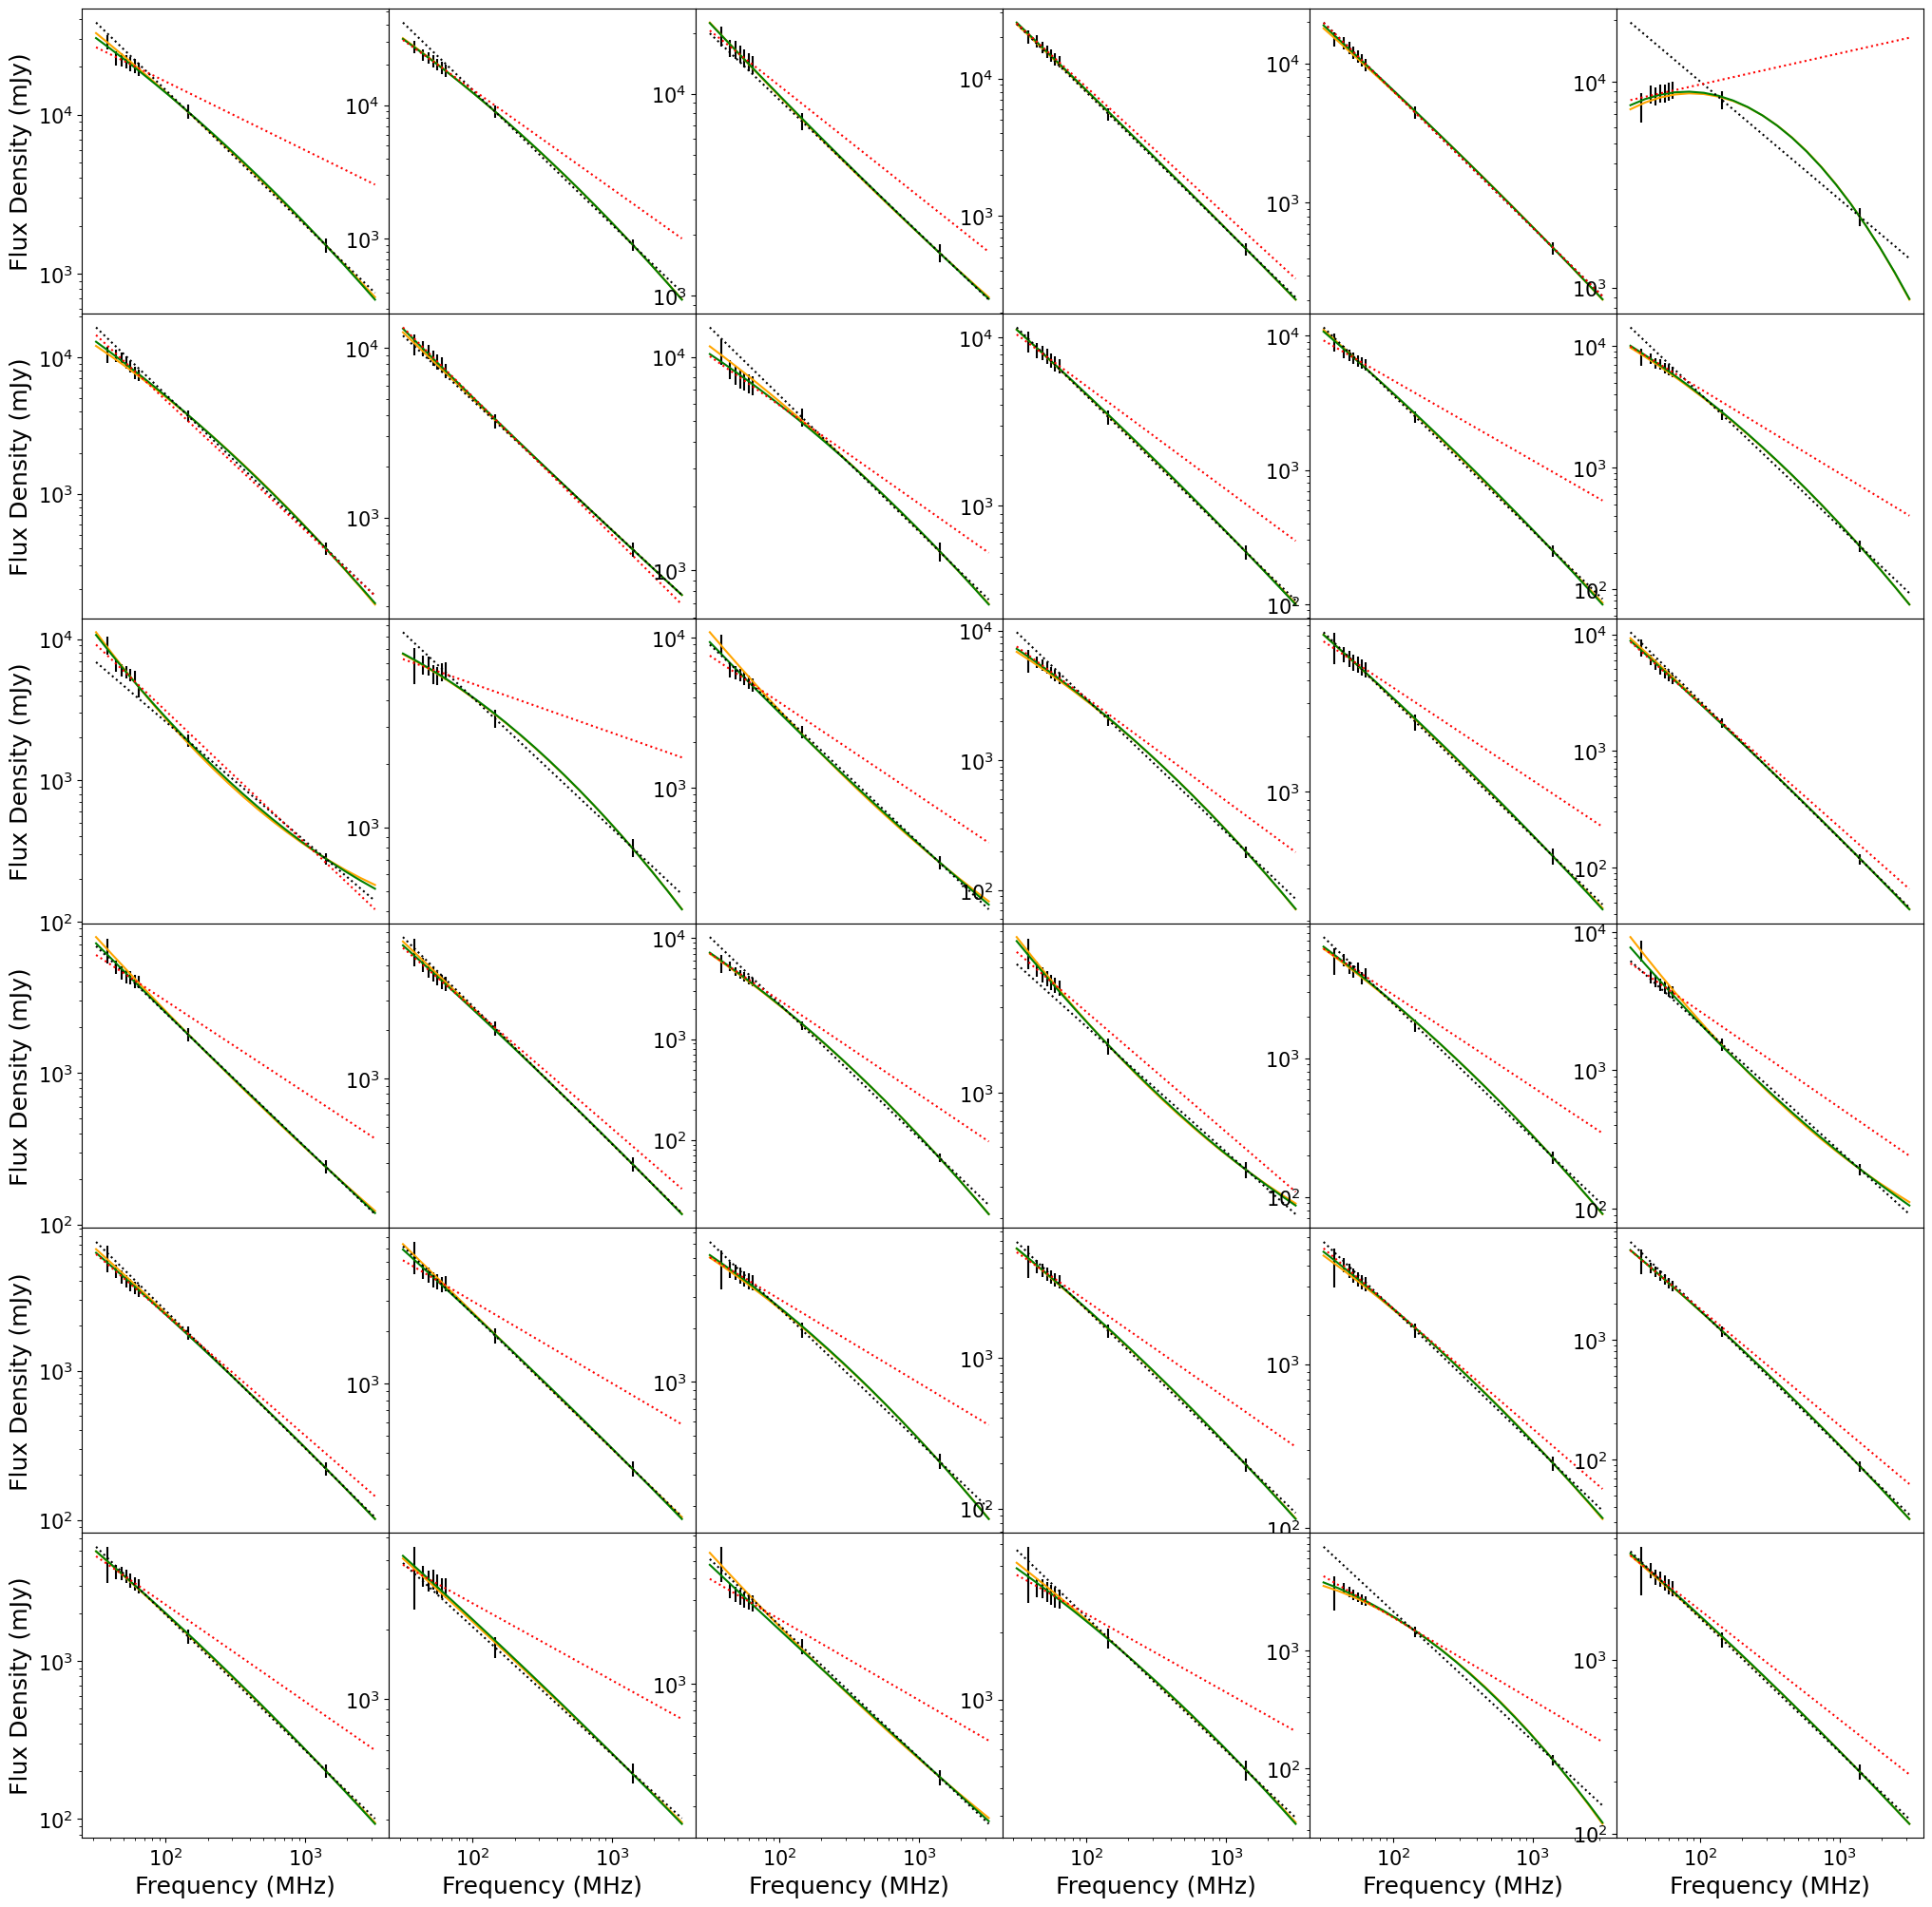

In [7]:
#####
cat_full = copy(cat_full_bkp)

cat_full.sort('flux_lolss', reverse=True)
idx = (cat_full['flux_lotss'] != 0) & (cat_full['flux_nvss'] != 0) & (cat_full['flux_8c'] != 0) & (cat_full['spidx_lolss'] != 0)#  & (cat_full['flux_lolss'] > 2900)

Ncurves = 36#sum(idx)
print('Ncurves:', Ncurves)

fig = plt.figure(figsize=(25,25))
fig.subplots_adjust(hspace=0, wspace=0)
s=0
for source in cat_full[idx][:42]:
    fluxes = [source['flux_lolss_%i' % i] for i in range(6)]
    fluxes_err = [get_err(source['flux_lolss_%i' % i], source['rms_lolss_%i' % i]) for i in range(6)]
    freqs = copy(lolss_inband_freqs)
    for survey in ['8c','lotss','nvss']:
        if source['flux_%s' % survey] != 0:
            fluxes += [source['flux_%s' % survey]]
            if survey == '8c': 
                freqs += [38]            
                fluxes_err += [get_err(source['flux_%s' % survey], 1000)]
            if survey == 'vlss': 
                freqs += [74]
                fluxes_err += [get_err(source['flux_%s' % survey], 100)]
            if survey == 'lotss': 
                freqs += [144] 
                fluxes_err += [get_err(source['flux_%s' % survey], 0.1)]
            if survey == 'nvss': 
                freqs += [1400]
                fluxes_err += [get_err(source['flux_%s' % survey], 0.45)]           
    
    fluxes = np.array(fluxes); fluxes_err = np.array(fluxes_err); freqs = np.array(freqs)
    p, p_err, _, _, _ = np.polyfit(np.log10(freqs[5:]), np.log10(fluxes[5:]), 2, full=True)
    # Reorder flux and freqs following freqs
    fluxes = fluxes[freqs.argsort()]
    fluxes_err = fluxes_err[freqs.argsort()]
    freqs = freqs[freqs.argsort()]
    pall, pall_err, _, _, _ = np.polyfit(np.log10(freqs), np.log10(fluxes), 2, full=True)
    if pall_err>0.01: continue

    ax = fig.add_subplot(int(np.ceil(np.sqrt(Ncurves))), int(np.ceil(np.sqrt(Ncurves))), s+1)
    #fluxes = 10**(np.log10(fluxes) - np.log10(source['flux_nvss']) + s)
    #ax.plot(freqs, fluxes,'k-', alpha=.1)
    #ax.plot(freqs, fluxes,'r.')
    ax.errorbar(freqs, fluxes, yerr=fluxes_err, ls='', color='k')
    #ax.errorbar(lolss_inband_freqs+[144,1400], fluxes, yerr=rms_lolss_c+[rms_lotss,rms_nvss], color='r', ls='')
 
    # second order interp (non LoLSS)
    ax.plot(np.logspace(1.5,3.5,20), 10**np.polyval(p, np.log10(np.logspace(1.5,3.5,20))), color='orange', ls="-")
    # second order interp (with LoLSS)
    ax.plot(np.logspace(1.5,3.5,20), 10**np.polyval(pall, np.log10(np.logspace(1.5,3.5,20))), color='green', ls="-")
    # linear interp of just lotss and nvss
    p = np.polyfit(np.log10([144,1400]), np.log10(fluxes[-2:]), 1)
    ax.plot(np.logspace(1.5,3.5,10), 10**np.polyval(p, np.log10(np.logspace(1.5,3.5,10))), color='black', ls=":")
    # linear interp using in-band
    p = np.polyfit(np.log10(lolss_inband_freqs), np.log10(fluxes[1:7]), 1)
    ax.plot(np.logspace(1.5,3.5,10), 10**np.polyval(p, np.log10(np.logspace(1.5,3.5,10))), color='red', ls=":")

    # plot in-band points not used for fit
    #fluxes = [source['flux_lolss_%i' % i] for i in range(6)]
    #fluxes_err = [get_err(source['flux_lolss_%i' % i], source['rms_lolss_%i' % i]) for i in range(6)]
    #freqs = copy(lolss_inband_freqs)
    #ax.errorbar(freqs, fluxes, yerr=fluxes_err, ls='', color='r')
    
    if s%6 == 0: ax.set_ylabel('Flux Density (mJy)')
    if s > 28: ax.set_xlabel('Frequency (MHz)')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.xaxis.label.set_fontsize(18)
    ax.yaxis.label.set_fontsize(18)    
    s += 1
    print(s,source['Source_name'],source['RA'],source['DEC'],source['spidx_lolss'],source['spidx_wide_low'],source['spidx_wide_high'])
    
    
fig.savefig('spectra.pdf', bbox_inches='tight')

(good points:4895)
[113.95692, 61.024271854496504, 11.124392] [8.231724417664573, 4.433054123274319, 1.0585081449808553]
spidx: [-0.74838239  3.40078309]
spidx in-band: [-0.31529458  2.61205241]
(good points:130)
[1691.3992, 1314.6125, 916.4847561796687, 155.2013] [150.80447124780466, 122.50295245913705, 83.42278654126478, 23.20412662923521]
spidx: [-0.78078236  4.6473366 ]
spidx 2nd order: [-0.18710061  0.21169106  3.37683276]
spidx in-band: [-0.36932386  3.87459612]
(good points:59)
[4900.0, 3981.0505, 1676.3169069216613, 220.99496] [917.1204016144693, 696.586477321496, 337.86779271866794, 66.54925897331299]
spidx: [-0.89087309  5.1471832 ]
spidx 2nd order: [-0.05473126 -0.60055163  4.7755314 ]
spidx in-band: [-0.40548717  4.27352901]


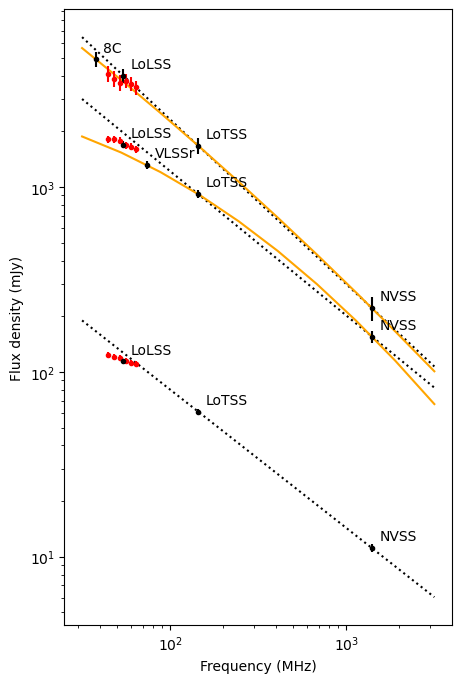

In [8]:
####################################################
# sigle spectrum

### plot NVSS+LOTSS (most sources)
cat_full = copy(cat_full_bkp)
idx = (cat_full['flux_nvss'] != 0) & (cat_full['flux_lotss'] != 0) & cat_full['is_pnt']
high_flux = cat_full[idx]['flux_nvss'] # NVSS
low_flux = cat_full[idx]['flux_lotss'] # LoTSS
lolss_flux = cat_full[idx]['flux_lolss']
spidx = np.log10(high_flux/low_flux)/np.log10(1400/144.)
# select good points - be sure all sources with spidx between -0.5 and -1.0 are included
idx_good = np.where((high_flux > rms_lolss*(1400/54.)**(-0.5)) & \
                    (low_flux > rms_lolss*(144/54.)**(-0.5)) & \
                    (high_flux > rms_lotss*(1400/144.)**(-0.5)) & \
                    (low_flux > rms_nvss*(144/1400.)**(-1.0)) & \
                    (lolss_flux > rms_lotss*(54/144.)**(-1.0)) & \
                    (lolss_flux > rms_nvss*(54/1400.)**(-1.0)) )
cat_full = cat_full[idx][idx_good]
print('(good points:%i)' % len(cat_full))

fig, ax1 = plt.subplots(ncols=1, figsize=(5,8), sharey=True)
fig.subplots_adjust(wspace=0)

# plot all
med_flux_lolss = np.median(cat_full['flux_lolss'])
err_flux_lolss = median_err(cat_full['flux_lolss'])
med_flux_lotss = np.median(cat_full['flux_lotss'])
err_flux_lotss = median_err(cat_full['flux_lotss'])
med_flux_nvss = np.median(cat_full['flux_nvss'])
err_flux_nvss = median_err(cat_full['flux_nvss'])
freqs = [54,144,1400]
fluxes = [med_flux_lolss,med_flux_lotss,med_flux_nvss]
fluxes_e = [err_flux_lolss, err_flux_lotss, err_flux_nvss]
print(fluxes, fluxes_e)

for i, survey in enumerate(['LoLSS','LoTSS','NVSS']):
    ax1.text(freqs[i]*1.1, fluxes[i]*1.1, survey)

p = np.polyfit(np.log10(freqs[1:]), np.log10(fluxes[1:]), 1)
ax1.plot(np.logspace(1.5,3.5,10), 10**np.polyval(p, np.log10(np.logspace(1.5,3.5,10))), color='black', ls=":")
print('spidx:',p)

med_flux_lolss_inband = [np.median(cat_full['flux_lolss_%i' % i]) for i in range(6)]
err_flux_lolss_inband = [median_err(cat_full['flux_lolss_%i' % i]) for i in range(6)]
#ax1.plot(lolss_inband_freqs, med_flux_lolss_inband, 'r.', ls='')
ax1.errorbar(lolss_inband_freqs, med_flux_lolss_inband, yerr=np.array(err_flux_lolss_inband)/2, color='red', ls='', marker='.')
#ax1.plot(freqs, fluxes, 'k.')
ax1.errorbar(freqs, fluxes, yerr=np.array(fluxes_e)/2, color='black', ls='', marker='.')

p = np.polyfit(np.log10(lolss_inband_freqs), np.log10(med_flux_lolss_inband), 1)
print('spidx in-band:',p)

### plot with VLSSr
cat_full = copy(cat_full_bkp)
idx = (cat_full['flux_nvss'] != 0) & (cat_full['flux_vlss'] != 0) & cat_full['is_pnt'] & (cat_full['flux_lotss'] != 0)
high_flux = cat_full[idx]['flux_nvss'] # NVSS
low_flux = cat_full[idx]['flux_vlss'] # VLSS
lolss_flux = cat_full[idx]['flux_lolss']
spidx = np.log10(high_flux/low_flux)/np.log10(1400/74.)
# select good points - be sure all sources with spidx between -0.5 and -1.0 are included
idx_good = np.where((high_flux > rms_lolss*(1400/54.)**(-0.5)) & \
                    (low_flux > rms_lolss*(74/54.)**(-0.5)) & \
                    (high_flux > rms_vlss*(1400/74.)**(-0.5)) & \
                    (low_flux > rms_nvss*(74/1400.)**(-1.0)) & \
                    (lolss_flux > rms_vlss*(54/74.)**(-1.0)) & \
                    (lolss_flux > rms_nvss*(54/1400.)**(-1.0)) )
cat_full = cat_full[idx][idx_good]
print('(good points:%i)' % len(cat_full))

med_flux_lolss = np.median(cat_full['flux_lolss'])
err_flux_lolss = median_err(cat_full['flux_lolss'])
med_flux_lotss = np.median(cat_full['flux_lotss'])
err_flux_lotss = median_err(cat_full['flux_lotss'])
med_flux_nvss = np.median(cat_full['flux_nvss'])
err_flux_nvss = median_err(cat_full['flux_nvss'])
med_flux_vlss = np.median(cat_full['flux_vlss'])
err_flux_vlss = median_err(cat_full['flux_vlss'])
freqs = [54,74,144,1400]
fluxes = [med_flux_lolss,med_flux_vlss,med_flux_lotss,med_flux_nvss]
fluxes_e = [err_flux_lolss, err_flux_vlss, err_flux_lotss, err_flux_nvss]
print(fluxes, fluxes_e)

for i, survey in enumerate(['LoLSS','VLSSr','LoTSS','NVSS']):
    ax1.text(freqs[i]*1.1, fluxes[i]*1.1, survey)

p = np.polyfit(np.log10(freqs[2:]), np.log10(fluxes[2:]), 1) # spidx only NVSS+LOTSS
ax1.plot(np.logspace(1.5,3.5,10), 10**np.polyval(p, np.log10(np.logspace(1.5,3.5,10))), color='black', ls=":")
print('spidx:',p)
p = np.polyfit(np.log10(freqs[1:]), np.log10(fluxes[1:]), 2)
ax1.plot(np.logspace(1.5,3.5,10), 10**np.polyval(p, np.log10(np.logspace(1.5,3.5,10))), color='orange', ls="-")
print('spidx 2nd order:',p)

med_flux_lolss_inband = [np.median(cat_full['flux_lolss_%i' % i]) for i in range(6)]
err_flux_lolss_inband = [median_err(cat_full['flux_lolss_%i' % i]) for i in range(6)]
#ax1.plot(lolss_inband_freqs, med_flux_lolss_inband, 'r.', ls='')
ax1.errorbar(lolss_inband_freqs, med_flux_lolss_inband, yerr=np.array(err_flux_lolss_inband)/2, color='red', ls='', marker='.')
#ax1.plot(freqs, fluxes, 'k.')
ax1.errorbar(freqs, fluxes, yerr=np.array(fluxes_e)/2, color='black', ls='', marker='.')

p = np.polyfit(np.log10(lolss_inband_freqs), np.log10(med_flux_lolss_inband), 1)
print('spidx in-band:',p)

### plot with 8c (no restrictions, too few sources)
cat_full = copy(cat_full_bkp)

idx = (cat_full['flux_nvss'] != 0) & (cat_full['flux_lotss'] != 0) & (cat_full['flux_8c'] != 0)
cat_full = cat_full[idx]
print('(good points:%i)' % len(cat_full))

med_flux_8c = np.median(cat_full['flux_8c'])
err_flux_8c = median_err(cat_full['flux_8c'])
med_flux_lolss = np.median(cat_full['flux_lolss'])
err_flux_lolss = median_err(cat_full['flux_lolss'])
med_flux_lotss = np.median(cat_full['flux_lotss'])
err_flux_lotss = median_err(cat_full['flux_lotss'])
med_flux_nvss = np.median(cat_full['flux_nvss'])
err_flux_nvss = median_err(cat_full['flux_nvss'])
freqs = [38,54,144,1400]
fluxes = [med_flux_8c, med_flux_lolss, med_flux_lotss, med_flux_nvss]
fluxes_e = [err_flux_8c, err_flux_lolss, err_flux_lotss, err_flux_nvss]
print(fluxes, fluxes_e)

for i, survey in enumerate(['8C','LoLSS','LoTSS','NVSS']):
    ax1.text(freqs[i]*1.1, fluxes[i]*1.1, survey)

p = np.polyfit(np.log10(freqs[2:]), np.log10(fluxes[2:]), 1) # spidx only NVSS+LOTSS
ax1.plot(np.logspace(1.5,3.5,10), 10**np.polyval(p, np.log10(np.logspace(1.5,3.5,10))), color='black', ls=":")
print('spidx:',p)
p = np.polyfit(np.log10([38]+freqs[2:]), np.log10([fluxes[0]]+fluxes[2:]), 2)
ax1.plot(np.logspace(1.5,3.5,10), 10**np.polyval(p, np.log10(np.logspace(1.5,3.5,10))), color='orange', ls="-")
print('spidx 2nd order:',p)

med_flux_lolss_inband = [np.median(cat_full['flux_lolss_%i' % i]) for i in range(6)]
err_flux_lolss_inband = [median_err(cat_full['flux_lolss_%i' % i]) for i in range(6)]
#ax1.plot(lolss_inband_freqs, med_flux_lolss_inband, 'r.', ls='')
ax1.errorbar(lolss_inband_freqs, med_flux_lolss_inband, yerr=np.array(err_flux_lolss_inband)/2, color='red', ls='', marker='.')
#ax1.plot(freqs, fluxes, 'k.')
ax1.errorbar(freqs, fluxes, yerr=np.array(fluxes_e)/2, color='black', ls='', marker='.')

p = np.polyfit(np.log10(lolss_inband_freqs), np.log10(med_flux_lolss_inband), 1)
print('spidx in-band:',p)

ax1.set_xlabel('Frequency (MHz)')
ax1.set_ylabel('Flux density (mJy)')

ax1.set_xscale('log')
ax1.set_yscale('log')

fig.savefig('single_spectrum.pdf', bbox_inches='tight')